## Baseline models

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV, QuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

In [4]:
# load database
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])
print(df.shape)
print(df.columns.tolist())

(62544, 60)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'd

### Scale down importance of earlier periods using weights

In [5]:
# Create weights assigned to each observation

df = df.sort_values("timestamp").set_index("timestamp")

def create_regime_weights(index):

    weights = pd.Series(1.0, index=index)

    # Pre-crisis
    weights.loc["2019-01-01 00:00":"2020-12-31 23:00"] = 0.6

    # Energy crisis
    weights.loc["2021-01-01 00:00":"2022-12-31 23:00"] = 0.3

    # Post-crisis
    weights.loc["2023-01-01 00:00":"2025-06-30 23:00"] = 1.0

    return weights

weights = create_regime_weights(df.index)

### Naive model (as in Biro et al)

In [6]:
# define a function that does the naive model

def predict_price_lag(df, price_col='price', day_col='day_of_week'):
    """
    Predict price using a conditional lag:
    - Tue, Wed, Thu, Fri, Sun → lag 1 (24h)
    - Sat, Mon → lag 7 (168h)
    """

    lag_1 = df[price_col].shift(24)
    lag_7 = df[price_col].shift(168)

    lag_1_days = {1, 2, 3, 4, 6}

    return pd.Series(
        np.where(df[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df.index
    )

In [7]:
# Predict with the naive model on the test data
df['price_pred_naive'] = predict_price_lag(df)

### Train-test split

In [8]:
# Fix the start of the test set
test_start = "2025-07-01"

(56592, 60)
(5952, 60)


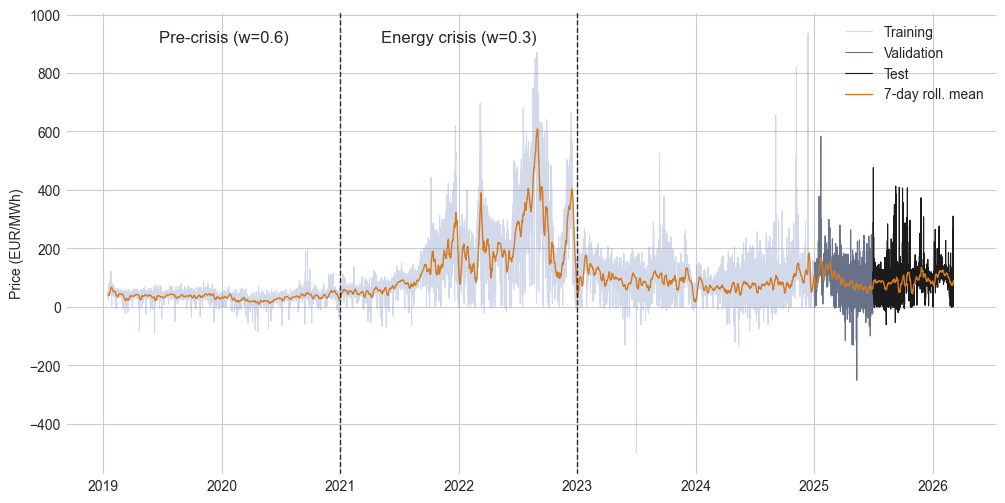

In [9]:
# Split data into train and test sample

train_df = df[df.index < test_start].copy()
test_df  = df[df.index >= test_start].copy()

validation_df = train_df[train_df.index >= "2025-01-01"]  # for now, just to show

print(train_df.shape)
print(test_df.shape)

# Plotting the train and test set
plt.figure(figsize=(12,6))

# Plot train and test
plt.plot(train_df.index, train_df['price'], color="#8DA0CB", linewidth=0.8, alpha=0.4, label='Training')
plt.plot(validation_df.index, validation_df['price'], color="#68738A", linewidth=0.8, label='Validation')
plt.plot(test_df.index, test_df['price'], color="#1B1B1B", linewidth=0.8, label='Test')

# 7-day rolling mean
plt.plot(df.index, df['price_rolling_168h'],
         color="#D37B22", linewidth=1,
         label='7-day roll. mean')

# Regime separator lines
plt.axvline(pd.Timestamp("2021-01-01 00:00"), color='black', linestyle='--', linewidth=1, alpha=0.8)
plt.axvline(pd.Timestamp("2023-01-01 00:00"), color='black', linestyle='--', linewidth=1, alpha=0.8)

# Label axes and legend
plt.xlabel("")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True)

# Add text to the regimes

# --- define regime boundaries ---
split1 = pd.Timestamp("2021-01-01 00:00")
split2 = pd.Timestamp("2023-01-01 00:00")

# y-position for text (near top of plot)
y_pos = plt.ylim()[1] * 0.9

# --- region midpoints ---
x_pre   = train_df.index.min() + (split1 - train_df.index.min()) / 2
x_crisis = split1 + (split2 - split1) / 2
x_post  = split2 + (df.index.max() - split2) / 2

# --- add labels ---
plt.text(x_pre, y_pos, "Pre-crisis (w=0.6)", ha='center', fontsize=12)
plt.text(x_crisis, y_pos, "Energy crisis (w=0.3)", ha='center', fontsize=12)
#plt.text(x_post, y_pos, "Post-crisis", ha='center', fontsize=12)

# Save figure
plt.savefig("../images/price_timeseries.png", dpi=300, bbox_inches="tight")

plt.show()

### Forecast evaluation

In [10]:
# Define metrics

# Daily Average Error (DAE)
def dae(y_true, y_pred):

    # Align indices
    common_index = y_true.index.intersection(y_pred.index)
    y_true = y_true.loc[common_index].sort_index()
    y_pred = y_pred.loc[common_index].sort_index()

    # Extract date for grouping
    forecast_date = pd.Series(y_true.index.date, index=y_true.index)

    # Compute daily mean
    daily_true_mean = y_true.groupby(forecast_date).mean()
    daily_pred_mean = y_pred.groupby(forecast_date).mean()

    # DAE: mean absolute difference of daily means
    return np.mean(np.abs(daily_true_mean - daily_pred_mean))


# Symmetric Mean Absolute Percentage Error (SMAPE)
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

In [11]:
# performance of naive prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_naive"])
smape_score = smape(test_df["price"], test_df["price_pred_naive"])
dae_score = dae(test_df["price"], test_df["price_pred_naive"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 23.3474
DAE: 18.8407
SMAPE: 37.6247


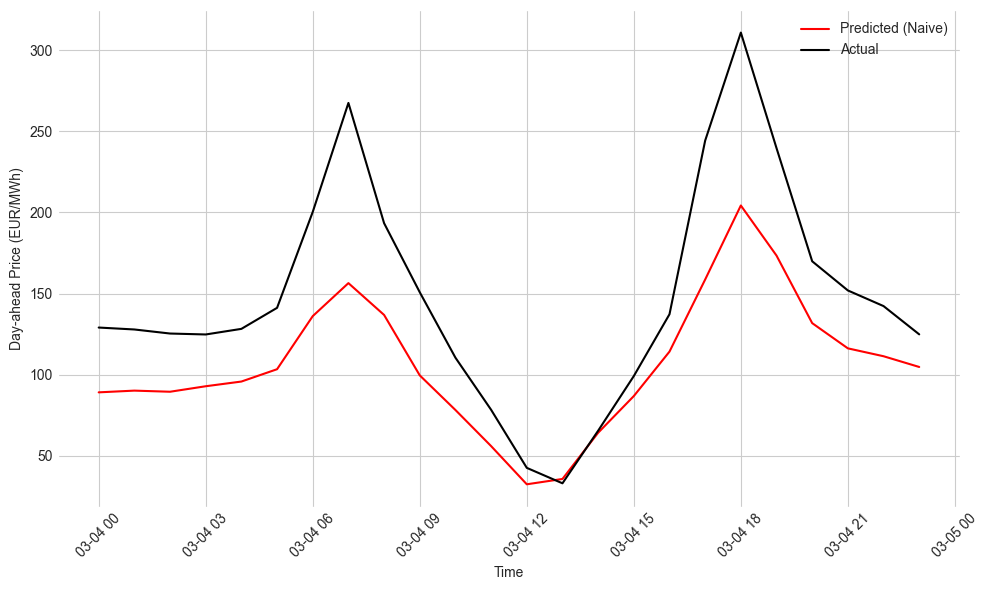

In [12]:
# Plotting true and forecasted for a specific day

day = "2026-03-04"

day_df = test_df.loc[day]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df.index, day_df['price_pred_naive'],
         color='red', label='Predicted (Naive)')

plt.plot(day_df.index, day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARX-LASSO

In [13]:
# function to generate all lags
def generate_hourly_lags(df, features, lags=None):
    if lags is None:
        lags = list(range(24, 73)) + list(range(168, 193))
    """
    Generate lagged features for hourly time series.

    Args:
        df: pandas DataFrame with DatetimeIndex (hourly)
        features: list of column names to generate lags for
        lags: list of integer lags in hours

    Returns:
        DataFrame with lagged features (columns named <feature>_lag_<lag>)
    """
    lagged_df = pd.DataFrame(index=df.index)

    for feature in features:
        for lag in lags:
            col_name = f"{feature}_{lag}h"
            lagged_df[col_name] = df[feature].shift(lag)

    return lagged_df

In [14]:
# list of features to be lagged
features = ["price", "total_generation", "net_export"]

# apply the lag function
lagged_features = generate_hourly_lags(df, features)

# add created lagged features to dataframe
df = pd.concat([df, lagged_features], axis=1)

C:\Users\Cecilia\AppData\Local\Temp\ipykernel_15604\2488092906.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged_df[col_name] = df[feature].shift(lag)
C:\Users\Cecilia\AppData\Local\Temp\ipykernel_15604\2488092906.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lagged_df[col_name] = df[feature].shift(lag)
C:\Users\Cecilia\AppData\Local\Temp\ipykernel_15604\2488092906.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

In [15]:
# Fuel prices 2 days ago -- the one-day-ago price is not yet available at the time of forecasting
df['gas_price_lag_48h'] = df['gas_price'].shift(48)
df['coal_price_lag_48h'] = df['coal_price'].shift(48)
df['co2_price_lag_48h'] = df['co2_price'].shift(48)

C:\Users\Cecilia\AppData\Local\Temp\ipykernel_15604\1148454360.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['gas_price_lag_48h'] = df['gas_price'].shift(48)
C:\Users\Cecilia\AppData\Local\Temp\ipykernel_15604\1148454360.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['coal_price_lag_48h'] = df['coal_price'].shift(48)
C:\Users\Cecilia\AppData\Local\Temp\ipykernel_15604\1148454360.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

In [16]:
lag_cols = [
    'price_24h', 'price_48h', 'price_72h', 'price_168h',
]

In [17]:
# feature set to be used in the models (modify as you like)
exog_features = [
    'load', 'wind_offshore', 'wind_onshore', 'solar',
    'load_ramp', 'renewable_ramp', 'delta_wind_forecast',
    'temperature', 'wind_speed',
    'net_export_48h', 'net_export_72h', 'net_export_168h',
    'total_generation_48h', 'total_generation_72h', 'total_generation_168h',
    'gas_price_lag_48h', 'coal_price_lag_48h', 'co2_price_lag_48h',
    'price_volatility_24h', 'is_weekend', 'is_holiday', 'is_peak_hour', "is_high_price_regime"
]

In [18]:
seasonal = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

In [19]:
# Split data with new features into train and test

train_df = df[df.index < test_start].copy()
test_df  = df[df.index >= test_start].copy()

train_df = train_df.dropna().copy()  # eliminate N/A from train (generated by lagging)

In [20]:
X_train = train_df[lag_cols + exog_features + seasonal]
y_train = train_df['price']

X_test = test_df[lag_cols + exog_features + seasonal]

In [21]:
# Standardize all features and lagged prices  (... shall we do it also on the sin and cosine time effects? )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# fit linear model with Lasso regularization

# you can experiment with different alphas
lasso = Lasso(alpha=0.5, max_iter=10000)
lasso.fit(X_train_scaled, y_train, sample_weight=weights.loc[X_train.index])

Lasso(alpha=0.5, max_iter=10000)

In [23]:
# predict on test-set
test_df['price_pred_arxlasso'] = lasso.predict(X_test_scaled)

In [24]:
# performance of ARX-LASSO prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_arxlasso"])
smape_score = smape(test_df["price"], test_df["price_pred_arxlasso"])
dae_score = dae(test_df["price"], test_df["price_pred_arxlasso"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 15.8580
DAE: 10.3803
SMAPE: 29.3322


In [25]:
# show features with non-zero coefficients
coef_series = pd.Series(lasso.coef_, index=lag_cols + exog_features + seasonal)
selected_features = coef_series[coef_series != 0].sort_values(ascending=False)
print(selected_features)

price_24h                42.063356
gas_price_lag_48h        19.521493
price_168h               10.863667
load                      9.277443
is_high_price_regime      8.637533
price_72h                 4.814213
price_volatility_24h      3.458356
dow_cos                   3.233245
co2_price_lag_48h         3.121051
temperature               0.797290
total_generation_168h     0.117774
wind_speed               -0.778228
month_cos                -1.171790
is_holiday               -1.204669
wind_offshore            -2.534964
is_weekend               -4.210799
delta_wind_forecast      -9.181647
wind_onshore             -9.247210
solar                   -11.205897
dtype: float64


In [26]:
# features dropped by lasso
discarded_features = coef_series[coef_series == 0].sort_values(ascending=False)
print(discarded_features)

price_48h               0.0
load_ramp               0.0
renewable_ramp         -0.0
net_export_48h          0.0
net_export_72h         -0.0
net_export_168h         0.0
total_generation_48h   -0.0
total_generation_72h   -0.0
coal_price_lag_48h      0.0
is_peak_hour           -0.0
hour_sin                0.0
hour_cos               -0.0
dow_sin                -0.0
month_sin              -0.0
dtype: float64


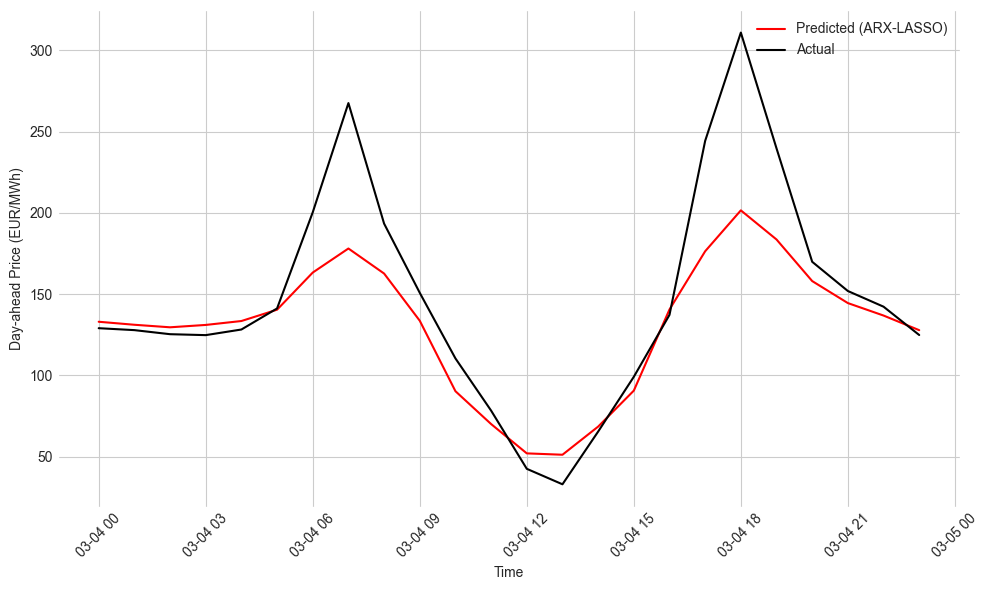

In [27]:
# Plotting true and forecasted for a specific day

day = "2026-03-04"

day_df = test_df.loc[day]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df.index, day_df['price_pred_arxlasso'],
         color='red', label='Predicted (ARX-LASSO)')

plt.plot(day_df.index, day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARX-LASSO with walk-forward CV

In [28]:
# Full training set up to June 30, 2025
train_df = df[df.index <= "2025-06-30 23:00:00"].copy()

train_df = train_df.dropna().copy()  # eliminate N/A from train (generated by lagging)

X_full = train_df[lag_cols + exog_features + seasonal]
y_full = train_df['price']

# CV period: Jan 1 → June 30, 2025
cv_start = pd.Timestamp("2025-01-01")
cv_end = pd.Timestamp("2025-06-30 23:00:00")

# Get CV indices (rows inside CV period)
cv_mask = (X_full.index >= cv_start) & (X_full.index <= cv_end)
X_cv = X_full[cv_mask]
y_cv = y_full[cv_mask]

# Hyperparameter grid
alphas = np.logspace(-1, 1.3, 20)

# Validation horizon
validation_days = 30
val_size = validation_days * 24  # hourly data

# TimeSeriesSplit for walk-forward CV
n_splits = (len(X_cv) - val_size) // val_size
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=val_size)

# ARX-LASSO pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

# Store CV results
results = []

for alpha in alphas:
    model.set_params(lasso__alpha=alpha)
    fold_scores = []

    for train_idx, val_idx in tscv.split(X_cv):
        # Train uses **all historical data before Jan 1, 2025 + CV training portion**
        X_train = pd.concat([X_full[X_full.index < cv_start], X_cv.iloc[train_idx]])
        y_train = pd.concat([y_full[y_full.index < cv_start], y_cv.iloc[train_idx]])

        X_val = X_cv.iloc[val_idx]
        y_val = y_cv.iloc[val_idx]

        model.fit(X_train, y_train, lasso__sample_weight=weights.loc[X_train.index])
        y_pred = model.predict(X_val)
        y_pred_series = pd.Series(y_pred, index=y_val.index)
        fold_scores.append(dae(y_val, y_pred_series))

    results.append({
        "alpha": alpha,
        "dae": np.mean(fold_scores)
    })

results = pd.DataFrame(results)
best_alpha = results.loc[results["dae"].idxmin(), "alpha"]

print(f"Best alpha: {best_alpha:.4f}")
print(f"Best CV DAE: {results['dae'].min():.4f}")

Best alpha: 0.1321
Best CV DAE: 8.5790


In [29]:
# --- Refit best model on full training data ---
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=best_alpha, max_iter=10000))
])

final_model.fit(X_full, y_full, lasso__sample_weight=weights.loc[X_full.index])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.13214557699755294, max_iter=10000))])

In [30]:
# show features with non-zero coefficients
lasso = final_model.named_steps["lasso"]
coef_series = pd.Series(lasso.coef_, index=lag_cols + exog_features + seasonal)
selected_features = coef_series[coef_series != 0].sort_values(ascending=False)
print(selected_features)

price_24h                42.138472
gas_price_lag_48h        19.963855
price_168h               11.221437
load                     11.086205
is_high_price_regime      8.079098
co2_price_lag_48h         4.031045
price_72h                 4.016611
price_volatility_24h      3.792641
dow_cos                   3.775782
temperature               2.230559
total_generation_168h     1.415384
hour_sin                  1.057471
net_export_48h            0.657087
net_export_168h           0.351943
is_peak_hour             -0.189412
renewable_ramp           -0.342647
net_export_72h           -0.396091
load_ramp                -0.461426
total_generation_48h     -0.759371
wind_speed               -1.234270
is_holiday               -1.309273
dow_sin                  -1.650079
month_cos                -1.983395
wind_offshore            -2.677025
is_weekend               -4.708650
wind_onshore             -9.357860
delta_wind_forecast      -9.447578
solar                   -13.523996
dtype: float64


In [31]:
# features dropped by lasso
discarded_features = coef_series[coef_series == 0].sort_values(ascending=False)
print(discarded_features)

price_48h               0.0
total_generation_72h    0.0
coal_price_lag_48h     -0.0
hour_cos               -0.0
month_sin              -0.0
dtype: float64


In [32]:
# Predict on test set
test_df = test_df.sort_index().copy()
X_test = test_df[lag_cols + exog_features + seasonal]
y_pred_test = final_model.predict(X_test)

# Add predictions to test_df
test_df["price_pred_bestlasso"] = y_pred_test

In [33]:
# performance of the best ARX-LASSO prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_bestlasso"])
smape_score = smape(test_df["price"], test_df["price_pred_bestlasso"])
dae_score = dae(test_df["price"], test_df["price_pred_bestlasso"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 15.8338
DAE: 10.3003
SMAPE: 29.3851


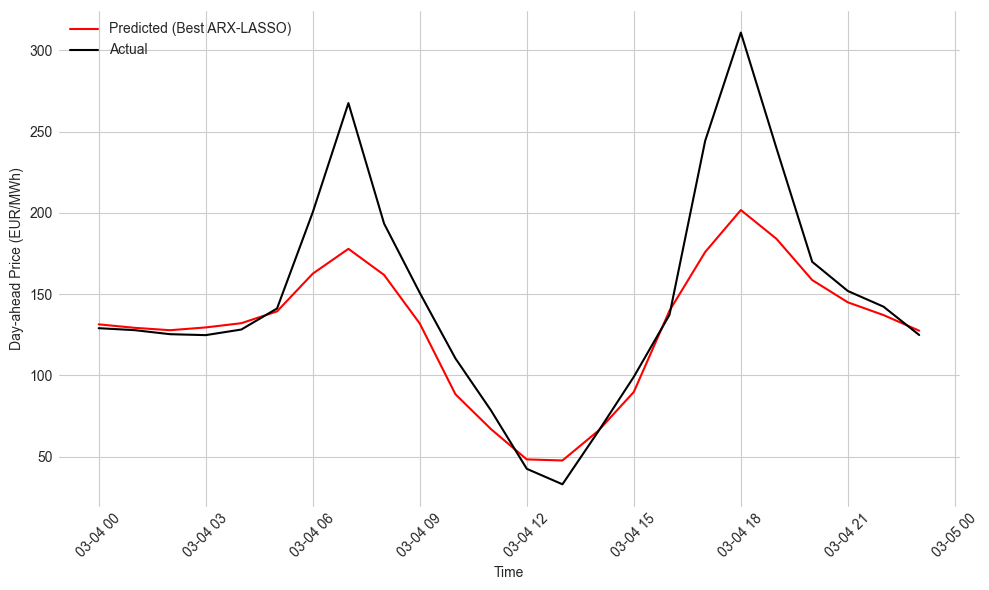

In [34]:
# Plotting true and forecasted for a specific day

day = "2026-03-04"

day_df = test_df.loc[day]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df.index, day_df['price_pred_bestlasso'],
         color='red', label='Predicted (Best ARX-LASSO)')

plt.plot(day_df.index, day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# for faster run --  not used eventually
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())


ModuleNotFoundError: No module named 'torch'

### Linear Quantile Regression

In [ ]:
# implement quantile regression with linear lasso model and the best alpha

percentiles = np.arange(0.25, 0.75, 0.05)  # 0.10, 0.20, ..., 0.90

quantile_pipelines = {}

for q in percentiles:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', QuantileRegressor(quantile=q, alpha=best_alpha, solver='highs'))
    ])
    pipe.fit(X_full, y_full, model__sample_weight=weights.loc[X_full.index])
    quantile_pipelines[q] = pipe

# Predict
predictions = {q: pipe.predict(X_full) for q, pipe in quantile_pipelines.items()}

forecast_df = pd.DataFrame(predictions)
forecast_df.columns = [f"Q{int(round(q*100))}" for q in percentiles]

### Plot a fan chart for a specific period

In [ ]:
# Make sure the index is the same as X_full
forecast_df.index = X_full.index
forecast_df.index = pd.to_datetime(forecast_df.index)  # just in case

NameError: name 'X_full' is not defined

In [ ]:
# Example: 1 July 2025 to 31 Dec 2025
start_date = pd.Timestamp("2024-08-01")
end_date   = pd.Timestamp("2024-08-07")

forecast_period = forecast_df.loc[(forecast_df.index >= start_date) & (forecast_df.index <= end_date)]
y_period = y_full.loc[forecast_period.index]

# Safety check
if forecast_period.empty:
    raise ValueError(f"No data found between {start_date} and {end_date}. Available range: {forecast_df.index.min()} – {forecast_df.index.max()}")

<Axes: xlabel='timestamp'>

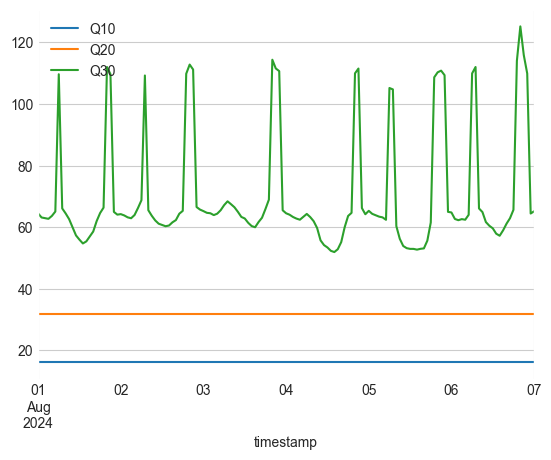

In [ ]:
forecast_period[["Q10","Q20","Q30"]].plot()  #--> flat predictions for the lowest two quantiles

In [ ]:
# Fan chart plotting

# X-axis
time_index = forecast_period.index

# Quantiles
quantiles = [int(col[1:]) for col in forecast_period.columns if col != "Q50"]
quantiles.sort()
lower_quantiles = [q for q in quantiles if q < 50]

# Color map
cmap = cm.get_cmap("Blues")

plt.figure(figsize=(14,6))

# Draw fan bands from outermost to inner (light → dark)
for i, q in enumerate(lower_quantiles[::-1]):  # reverse so outermost drawn first
    low  = f"Q{q}"
    high = f"Q{100-q}"

    # intensity: darker near median
    dist = 50 - q
    max_dist = 50 - min(lower_quantiles)
    strength = 0.25 + 0.7 * (1 - dist / max_dist)
    alpha = 0.25 + 0.5 * (1 - dist / max_dist)

    plt.fill_between(
        time_index,
        forecast_period[low],
        forecast_period[high],
        color=cmap(strength),
        alpha=alpha,
        linewidth=0
    )

# Median line
plt.plot(
    time_index,
    forecast_period["Q50"],
    color="navy",
    linewidth=2,
    label="Median forecast"
)

# Actual values
plt.plot(
    time_index,
    y_period.values,
    color="orange",
    linewidth=1,
    label="Actual"
)

# Formatting
#plt.ylim(bottom=0)
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Fan Chart – 1 July to 31 Dec 2025")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'forecast_period' is not defined